## EDA

This notebook is for obtaining information about the classes distibution and the data itself.

In [21]:
from pathlib import Path

ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / "Data"
TEST_DIR = ROOT / "TEST"

In [22]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [23]:
ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / "Data"
TEST_DIR = ROOT / "TEST"

print("DATA_DIR:", DATA_DIR)
print("TEST_DIR:", TEST_DIR)

DATA_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\Data
TEST_DIR: C:\Users\ibf\Desktop\TFM\Nou_projecte\TEST


In [24]:
from collections import Counter
from pathlib import Path
import os

def get_class_counts_recursive(folder):
    counts = Counter()

    for class_dir in Path(folder).iterdir():
        if class_dir.is_dir():
            label = class_dir.name

            for root, _, files in os.walk(class_dir):
                image_files = [
                    f for f in files
                    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff"))
                ]
                counts[label] += len(image_files)

    return counts

In [25]:
data_counts = get_class_counts_recursive(DATA_DIR)
test_counts = get_class_counts_recursive(TEST_DIR)

# Merge them
total_counts = data_counts + test_counts

In [26]:
import pandas as pd

df_counts = pd.DataFrame({
    "class": list(total_counts.keys()),
    "count": list(total_counts.values())
}).sort_values(by="count", ascending=False)

df_counts

,class,count
6,Revisión circuito,3736
4,Error terminal,1336
2,Error aplicativo,759
1,Cierre aplicación,606
3,Error funcional,597
7,Timeout,418
0,Banner aplicación,219
5,Indeterminado,56


C:\Users\ibf\AppData\Local\Temp\ipykernel_21916\2749842459.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


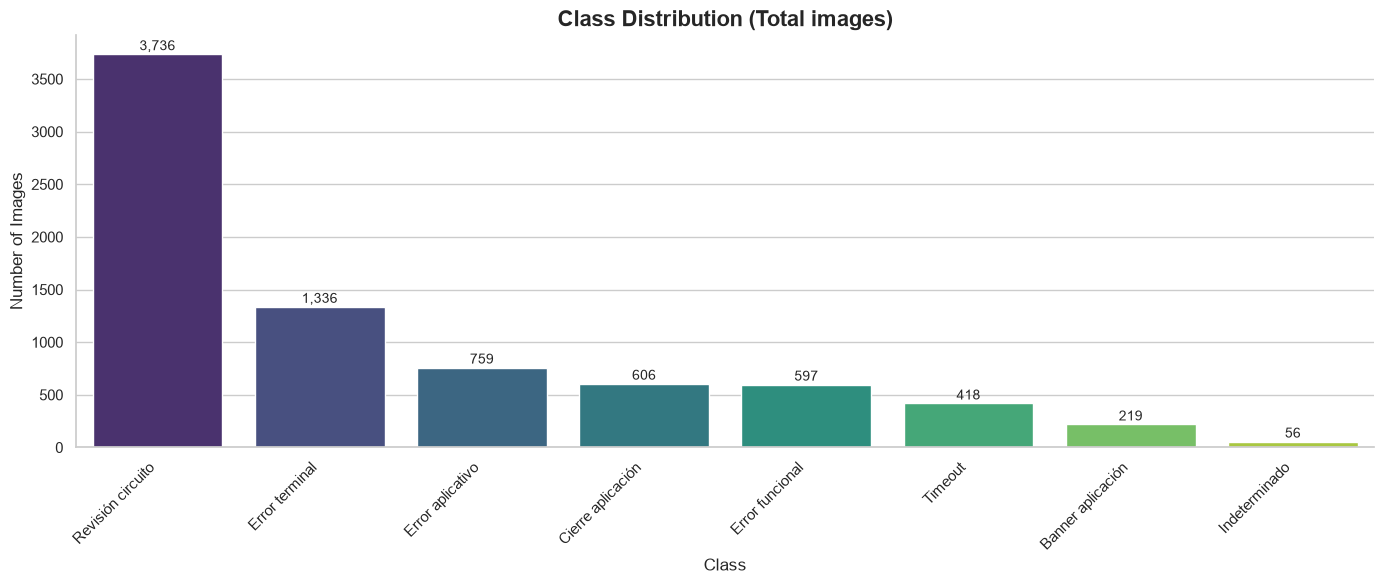

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort descending for vertical plot
df_counts = df_counts.sort_values("count", ascending=False)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_counts,
    x="class",
    y="count",
    palette="viridis"
)

# Add value labels on top of each bar
for i, v in enumerate(df_counts["count"]):
    ax.text(
        i,
        v + max(df_counts["count"]) * 0.01,  # small offset
        f"{v:,}",
        ha='center',
        fontsize=10
    )

plt.title("Class Distribution (Total images)", fontsize=16, weight='bold')
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=45, ha="right")
sns.despine()

plt.tight_layout()
plt.show()